In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dcor
import re
import json
import seaborn as sns
import scipy.stats as stats
from pathlib import Path
from scipy.stats import linregress
from matplotlib.ticker import ScalarFormatter
from src.utils import collect_sweep_learning_curves, collect_run_snapshots
from src.analysis import collect_sweep_metrics, aggregate_displacement_sweep

SWEEP_PATH = Path("training_runs/mnist_mlp_sweep")

curves_df = collect_sweep_learning_curves(SWEEP_PATH)
# sweep_df = collect_sweep_metrics(SWEEP_PATH)
# aggregate_displacement_sweep(SWEEP_PATH, output_name="displacement_database.parquet")

Found 45 training runs. Aggregating logs...
Success! Combined 29295 training steps into master log.


<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_717322/4200775222.py:47: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma$ = {s_val}", fontweight="bold", fontsize=12)


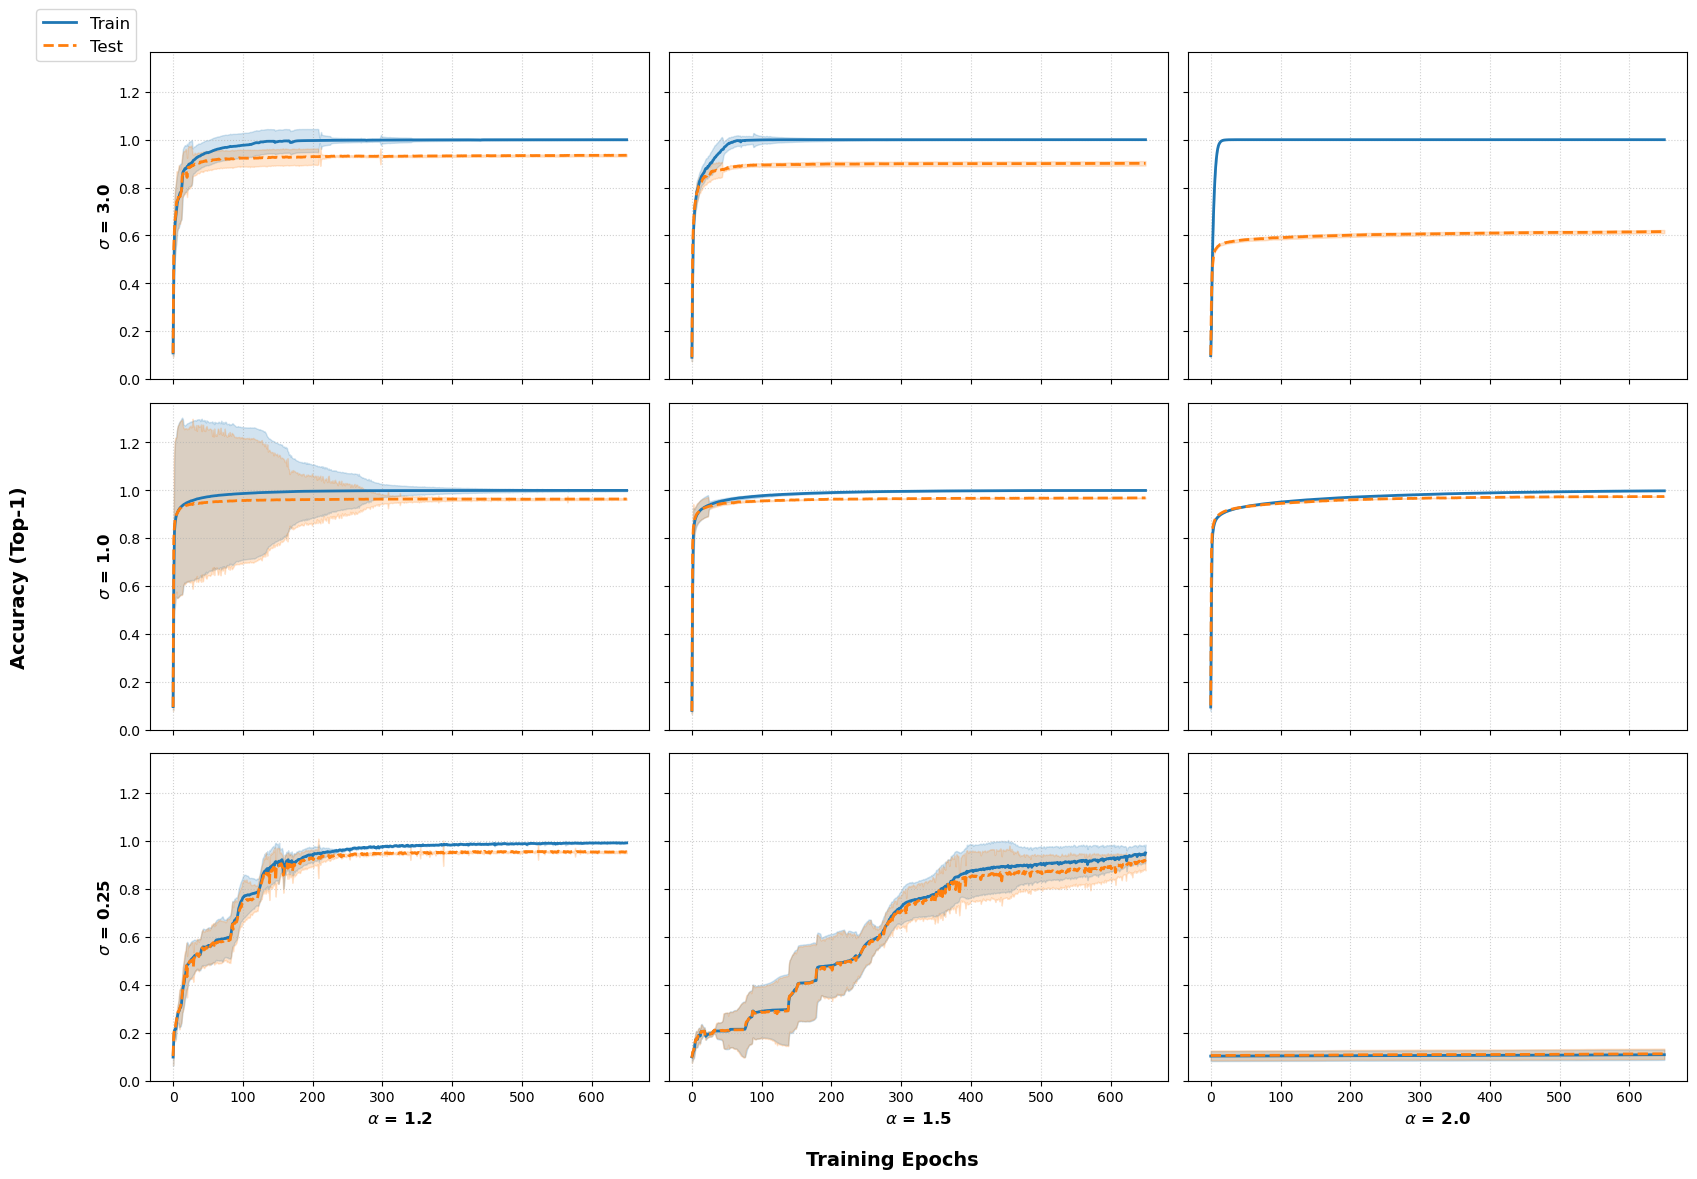

In [9]:
def plot_performance_facets(df, metric="loss"):
    """
    Plots training and test trajectories across the sweep grid.
    Supports multi-seed aggregation using Standard Deviation.
    metric: "loss" or "acc" (handles column naming automatically)
    """
    # 1. Coordinate Column Names
    # If your CSV columns are 'train_loss'/'test_loss' or 'train_acc'/'test_acc'
    train_col = f"train_{metric}"
    test_col = f"test_{metric}"
    ylabel = "Loss (Cross Entropy)" if metric == "loss" else "Accuracy (Top-1)"

    # 2. Setup Grid
    alphas = sorted(df["alpha"].unique())
    sigmas = sorted(df["sigma"].unique(), reverse=True)

    fig, axes = plt.subplots(
        len(sigmas), len(alphas), figsize=(18, 12), sharex=True, sharey=True, dpi=100
    )

    for i, s_val in enumerate(sigmas):
        for j, a_val in enumerate(alphas):
            ax = axes[i, j]

            # Filter for the specific subplot
            subset = df[(df["alpha"] == a_val) & (df["sigma"] == s_val)]

            if not subset.empty:
                ax.grid(True, linestyle=":", alpha=0.6)

                # --- TRAIN LINE (Mean + SD) ---
                sns.lineplot(
                    data=subset, x="epoch", y=train_col,
                    ax=ax, color="#1f77b4", lw=2,
                    label="Train", estimator="median", errorbar="sd"
                )

                # --- TEST LINE (Mean + SD) ---
                sns.lineplot(
                    data=subset, x="epoch", y=test_col,
                    ax=ax, color="#ff7f0e", lw=2, linestyle="--",
                    label="Test", estimator="median", errorbar="sd"
                )

            # Aesthetics
            if j == 0:
                ax.set_ylabel(f"$\sigma$ = {s_val}", fontweight="bold", fontsize=12)
            else:
                ax.set_ylabel("")

            if i == len(sigmas) - 1:
                ax.set_xlabel(f"$\\alpha$ = {a_val}", fontweight="bold", fontsize=12)
            else:
                ax.set_xlabel("")

            # Hide individual legends to clean up the grid
            ax.get_legend().remove()

    # 3. Global Labels and Legend
    fig.text(0.5, 0.01, "Training Epochs", ha="center", fontsize=14, fontweight="bold")
    fig.text(
        0.01, 0.5, ylabel,
        va="center", rotation="vertical", fontsize=14, fontweight="bold",
    )

    # Place a single legend for the whole figure
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="upper left", bbox_to_anchor=(0.02, 0.98),
        fontsize=12, frameon=True
    )

    plt.tight_layout(rect=[0.05, 0.03, 0.95, 0.95])
    # plt.savefig(f"performance_{metric}_sweep.pdf", bbox_inches="tight")
    plt.show()


def print_performance_summary_table(master_df):
    """
    Groups by run, extracts the final epoch values,
    calculates the generalization gap, and prints a summary.
    """
    # 1. Identify the last epoch for every unique run
    # We group by alpha and sigma (and run_id just in case of multiple seeds)
    summary = (
        master_df.sort_values("epoch")
        .groupby(["init_alpha", "init_sigma", "run_id"])
        .tail(1)
        .copy()
    )

    # 2. Calculate the Generalization Gap
    # Gap = Train Accuracy - Test Accuracy
    summary["gen_gap"] = summary["train_acc"] - summary["test_acc"]

    # 3. Select and rename columns for a clean display
    display_df = summary[
        ["init_alpha", "init_sigma", "train_acc", "test_acc", "gen_gap"]
    ].copy()

    # 4. Sort by sigma (descending) then alpha (ascending) to match your 3x3 plot logic
    display_df = display_df.sort_values(
        ["init_sigma", "init_alpha"], ascending=[False, True]
    )

    # 5. Print with nice formatting
    print("\n" + "=" * 80)
    print("FINAL PERFORMANCE SUMMARY TABLE")
    print("=" * 80)
    # Using tabulate or just pandas string formatting
    print(
        display_df.to_string(
            index=False, justify="center", float_format=lambda x: f"{x:.4f}"
        )
    )
    print("=" * 80)

    return display_df


# Usage:
final_stats_df = plot_performance_facets(curves_df, metric="acc")

<>:91: SyntaxWarning: invalid escape sequence '\D'
<>:93: SyntaxWarning: invalid escape sequence '\s'
<>:91: SyntaxWarning: invalid escape sequence '\D'
<>:93: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_735451/686645986.py:91: SyntaxWarning: invalid escape sequence '\D'
  ylabel_map = {"absolute": "", "relative": "(Rel)", "delta": "($\Delta$)"}
/tmp/ipykernel_735451/686645986.py:93: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma$={s_val} {ylabel_map[mode]}", fontweight="bold")


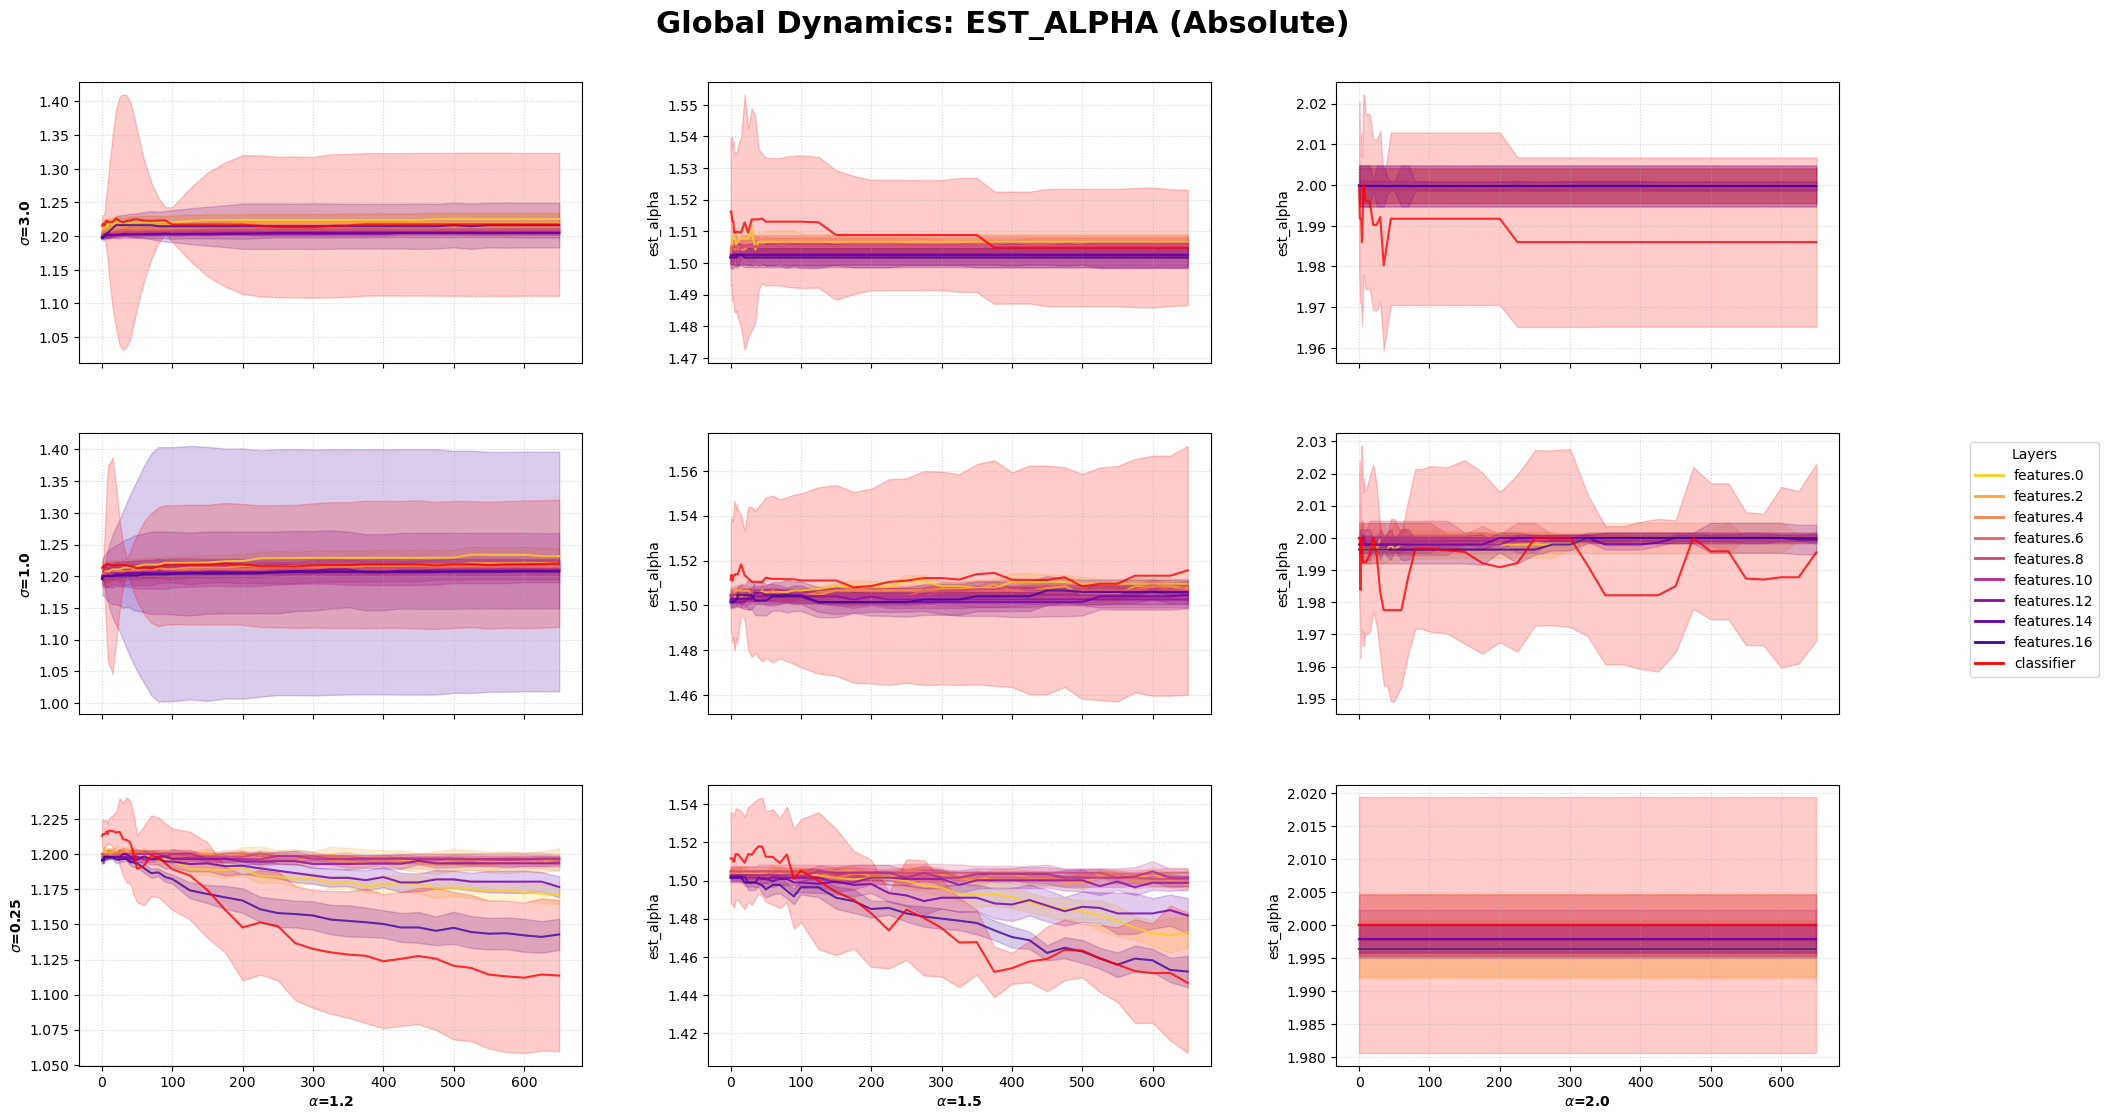

In [30]:
# 1. Load Parquet instead of CSV
sweep_df = pd.read_parquet("results/sweep_metrics.parquet")

def plot_combined_sweep_grid(
    df, metric_col="frobenius", ignore_classifier=False, plot_ratio=False, mode="absolute"
):
    """
    mode: "absolute" (raw values),
          "relative" (X_t / X_0),
          "delta" (X_t - X_0)
    """
    # Setup Grid Dimensions
    alphas = sorted(df["alpha_init"].unique())
    sigmas = sorted(df["sigma_init"].unique(), reverse=True)

    # Natural Sort Logic for Layers
    def extract_number(s):
        nums = re.findall(r"\d+", s)
        return int(nums[0]) if "classifier" not in s else 999

    all_layers = sorted(df["layer"].unique(), key=extract_number)
    hidden_layers = [l for l in all_layers if "classifier" not in l]
    classifier_layer = [l for l in all_layers if "classifier" in l]

    # Color Logic
    hidden_colors = sns.color_palette("plasma_r", len(hidden_layers))
    layer_to_color = {l: hidden_colors[i] for i, l in enumerate(hidden_layers)}
    for l in classifier_layer:
        layer_to_color[l] = "red"

    fig, axes = plt.subplots(
        len(sigmas), len(alphas), figsize=(22, 12), sharex=True, sharey=False
    )

    target_col = metric_col

    for i, s_val in enumerate(sigmas):
        for j, a_val in enumerate(alphas):
            ax = axes[i, j]

            mask = (df["alpha_init"] == a_val) & (df["sigma_init"] == s_val)
            run_subset = df[mask].copy()

            if not run_subset.empty:

                # --- DYNAMIC NORMALIZATION/DELTA LOGIC ---
                if mode in ["relative", "delta"]:
                    def compute_change(group):
                        x0 = group.iloc[0]
                        # Safety Threshold: if init is effectively 0, avoid math artifacts
                        if abs(x0) < 1e-8:
                            return group * 0 if mode == "delta" else group * 0 + 1.0

                        if mode == "relative":
                            return group / x0
                        else: # delta
                            return group - x0

                    run_subset[f"{metric_col}_{mode}"] = run_subset.groupby(['seed', 'layer'])[metric_col].transform(compute_change)
                    target_col = f"{metric_col}_{mode}"

                if plot_ratio:
                    # --- RATIO LOGIC (Classifier vs Hidden Median) ---
                    pivoted = run_subset.pivot_table(
                        index=["seed", "epoch"],
                        columns="layer",
                        values=target_col
                    )
                    hidden_median = pivoted[hidden_layers].median(axis=1)
                    cls_val = pivoted[classifier_layer[0]]
                    pivoted['ratio'] = cls_val / (hidden_median + 1e-12)

                    sns.lineplot(
                        data=pivoted.reset_index(), x="epoch", y="ratio",
                        ax=ax, color="red", lw=2.5, estimator="median", errorbar="sd"
                    )
                    ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.3)
                else:
                    # --- LAYER-WISE LOGIC ---
                    if ignore_classifier:
                        run_subset = run_subset[~run_subset["layer"].str.contains("classifier")]

                    sns.lineplot(
                        data=run_subset, x="epoch", y=target_col, hue="layer",
                        palette=layer_to_color, ax=ax, legend=False,
                        estimator="median", errorbar="sd", alpha=0.8
                    )

            # Aesthetics
            ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
            ylabel_map = {"absolute": "", "relative": "(Rel)", "delta": "($\Delta$)"}
            if j == 0:
                ax.set_ylabel(f"$\sigma$={s_val} {ylabel_map[mode]}", fontweight="bold")
            if i == len(sigmas) - 1:
                ax.set_xlabel(f"$\\alpha$={a_val}", fontweight="bold")
            ax.grid(True, linestyle=":", alpha=0.5)

    # Legend and Titles
    handles = [plt.Line2D([0], [0], color=layer_to_color[l], lw=2) for l in all_layers
               if not (ignore_classifier and "classifier" in l)]
    clean_labels = [l.replace(".weight", "") for l in all_layers
                    if not (ignore_classifier and "classifier" in l)]
    fig.legend(handles, clean_labels, loc="center right", title="Layers", frameon=True)

    plt.suptitle(f"Global Dynamics: {metric_col.upper()} ({mode.capitalize()})",
                 fontsize=22, y=0.96, fontweight="bold")
    fig.subplots_adjust(top=0.90, bottom=0.08, left=0.08, right=0.88, hspace=0.25, wspace=0.25)
    plt.show()

# Example: Plotting the change (Delta) in Stable Rank
plot_combined_sweep_grid(sweep_df, metric_col="est_alpha", mode="absolute")

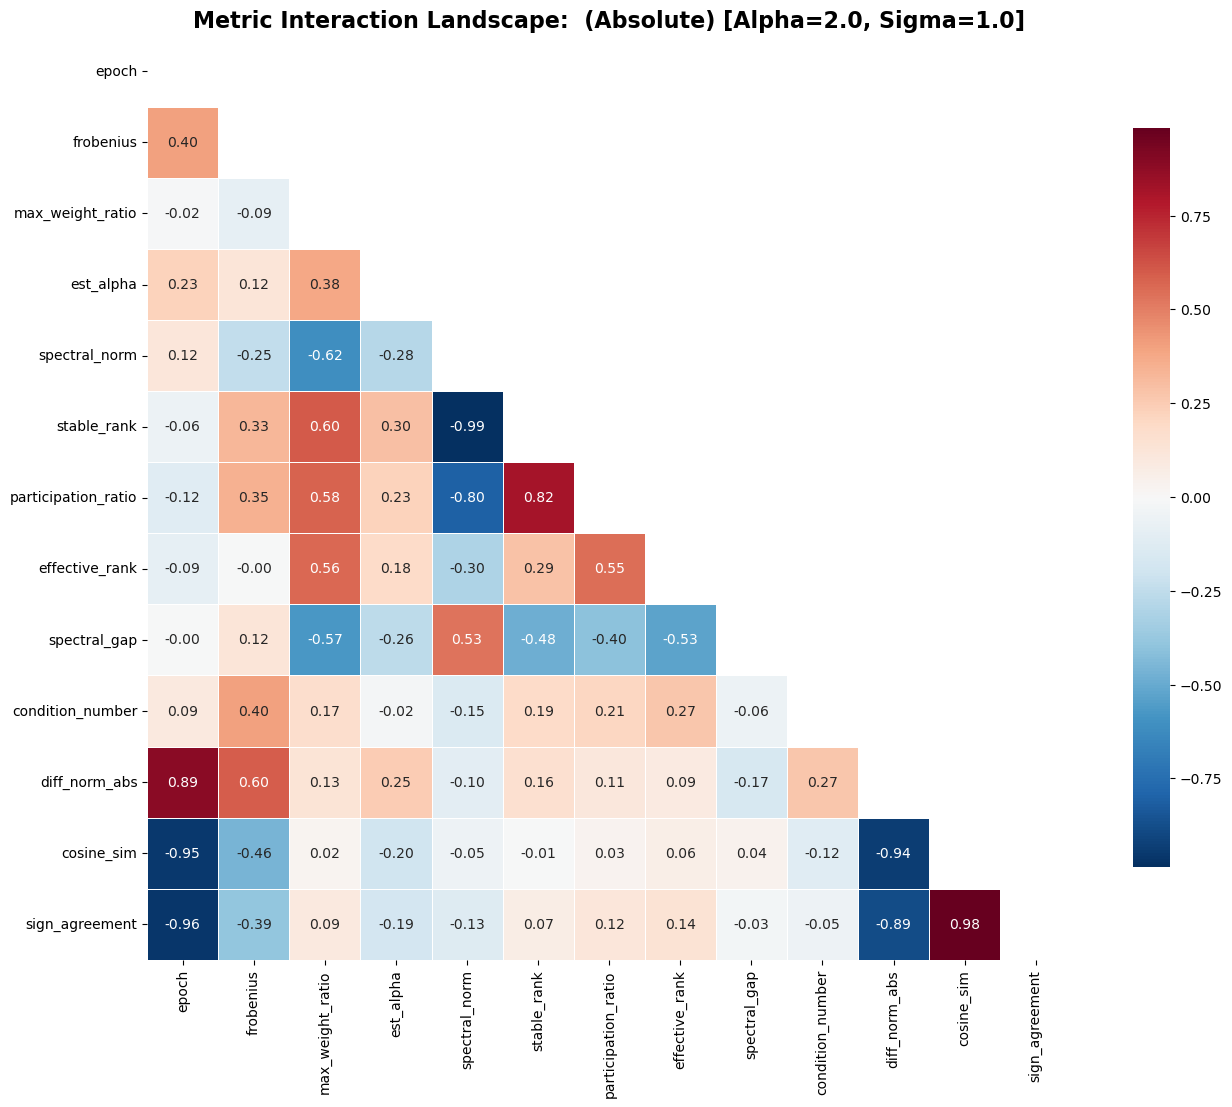

In [ ]:
sweep_df = pd.read_parquet("results/sweep_metrics.parquet")

def plot_metric_correlation(df, sweep_config=None, mode="delta"):
    """
    Automatically identifies metrics and computes correlations.
    mode: "absolute", "delta" (X_t - X_0), or "relative" (X_t / X_0)
    """
    plot_df = df.copy()

    # 1. Automatic Metric Selection
    # Drop columns we know are metadata/parameters
    exclude_cols = ['epoch', 'alpha_init', 'sigma_init', 'seed', 'run_name', 'layer']

    # Select only numeric columns and drop the metadata ones
    metrics = plot_df.select_dtypes(include=[np.number]).columns.tolist()
    available_metrics = [m for m in metrics if m not in exclude_cols]

    # 2. Dynamic mode calculation
    if mode in ["delta", "relative"]:
        for m in available_metrics:
            def compute_transform(group):
                x0 = group.iloc[0]
                # Safety check for FP precision / zero-init
                if abs(x0) < 1e-8:
                    return group * 0 if mode == "delta" else group * 0 + 1.0
                return (group - x0) if mode == "delta" else (group / x0)

            # Apply transformation per unique run
            new_col = f"{mode[:1].upper()}_{m}" # D_metric or R_metric
            plot_df[new_col] = plot_df.groupby('run_name')[m].transform(compute_transform)

        # Update list to use the transformed columns
        cols_to_corr = [f"{mode[:1].upper()}_{m}" for m in available_metrics]
    else:
        cols_to_corr = available_metrics

    # 3. Filter for specific regime
    title_suffix = f" ({mode.capitalize()})"
    if sweep_config:
        for key, val in sweep_config.items():
            if key in plot_df.columns:
                plot_df = plot_df[plot_df[key] == val]
        title_suffix += f" [Alpha={sweep_config.get('alpha_init')}, Sigma={sweep_config.get('sigma_init')}]"

    # Always keep epoch for time-correlation
    final_cols = ['epoch'] + cols_to_corr

    # 4. Compute Correlation
    corr_matrix = plot_df[final_cols].corr(method='spearman')

    # 5. Plotting
    plt.figure(figsize=(16, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # Use different colormaps for different modes to stay visually organized
    cmap = "RdBu_r" if mode == "absolute" else "PiYG" if mode == "delta" else "BrBG"

    sns.heatmap(
        corr_matrix, annot=True, fmt=".2f", cmap=cmap, center=0,
        mask=mask, square=True, linewidths=.5, cbar_kws={"shrink": .8}
    )

    plt.title(f"Metric Interaction Landscape: {title_suffix}", fontsize=16, fontweight='bold')
    plt.show()

# Run the dynamic analysis
plot_metric_correlation(sweep_df, mode="absolute", sweep_config={'alpha_init': 2.0, 'sigma_init': 1.0})

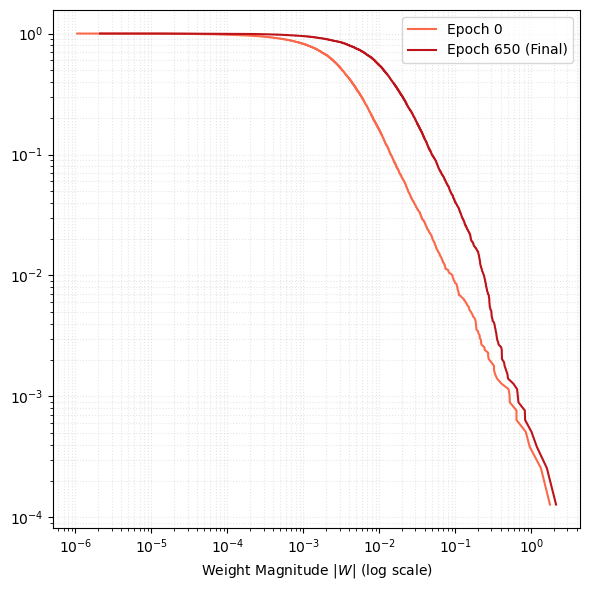

CCDF analysis complete.


In [ ]:
def plot_weight_ccdf(
    sweep_dir,
    target_alpha=1.2,
    target_sigma=0.25,
    epochs_to_plot=[0, 45],
    layer_name="classifier.weight",
):
    """
    Loads weights from the sweep and plots the Log-Log CCDF to visualize tails.
    Uses robust path logic from the reference collection function.
    """
    sweep_path = Path(sweep_dir)
    config_files = list(sweep_path.rglob("run_config.json"))

    if not config_files:
        print(f"No run_config.json files found in {sweep_dir}")
        return

    plt.figure(figsize=(6, 6))

    for cfg_path in config_files:
        with open(cfg_path, "r") as f:
            cfg = json.load(f)

        # Only look at the run with your target init_alpha
        # HT config 'alpha' corresponds to your initialization alpha
        if (
            cfg["ht_config"].get("alpha") != target_alpha
            or cfg["ht_config"].get("g") != target_sigma
        ):
            continue

        run_dir = cfg_path.parent
        ckpt_dir = run_dir / "checkpoints"
        final_epoch = cfg["hyperparams"].get("epochs")

        # Get all available checkpoints in this run
        all_ckpts = list(ckpt_dir.glob("*.pth"))

        for i, epoch in enumerate(epochs_to_plot):
            # Logic to find the correct file for the requested epoch
            ckpt_path = None

            if epoch == -1 or epoch == final_epoch:
                target_path = ckpt_dir / "final_model.pth"
                if target_path.exists():
                    ckpt_path = target_path
            else:
                # Search for the specific epoch pattern
                pattern = f"weights_epoch_{epoch}.pth"
                target_path = ckpt_dir / pattern
                if target_path.exists():
                    ckpt_path = target_path

            if ckpt_path is None:
                print(f"Skipping: Epoch {epoch} not found in {ckpt_dir}")
                continue

            # Load weights using the reference's robust loading logic
            try:
                ckpt_data = torch.load(ckpt_path, map_location="cpu", weights_only=True)
                # Handle different state_dict saving conventions
                state_dict = ckpt_data.get(
                    "model_state", ckpt_data.get("state_dict", ckpt_data)
                )

                colors = plt.cm.Reds(np.linspace(0.5, 0.8, len(epochs_to_plot)))
                if layer_name in state_dict:
                    # Conversion logic from reference (handle bfloat16 artifacts if needed)
                    tensor = state_dict[layer_name]
                    if "final_model" in ckpt_path.name:
                        weights = (
                            tensor.to(torch.bfloat16)
                            .to(torch.float32)
                            .numpy()
                            .flatten()
                        )
                    else:
                        weights = tensor.to(torch.float32).numpy().flatten()

                    # Statistical sorting for CCDF
                    abs_weights = np.sort(np.abs(weights))[::-1]

                    # P(|W| > x)
                    y = np.arange(1, len(abs_weights) + 1) / len(abs_weights)

                    label = (
                        f"Epoch {epoch}"
                        if epoch != final_epoch
                        else f"Epoch {epoch} (Final)"
                    )
                    plt.loglog(abs_weights, y, color=colors[i], label=label)

                del ckpt_data
                del state_dict

            except Exception as e:
                print(f"Error loading {ckpt_path}: {e}")

    # Formatting the plot
    # plt.title(f"Log-Log CCDF for {layer_name}\n(Initial $\\alpha={target_alpha}$)")
    plt.xlabel("Weight Magnitude $|W|$ (log scale)")
    # plt.xlim(1e-9, 1e2)  # Adjust as needed based on expected weight ranges
    # plt.ylabel("$P(|W| > x)$ (log scale)")
    # plt.ylim(1e-6, 1)  # Adjust based on expected tail probabilities
    plt.grid(True, which="both", ls=":", alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(
        f"ccdf_{layer_name}_alpha_{target_alpha}_sigma_{target_sigma}.pdf",
        bbox_inches="tight",
    )
    plt.show()
    print("CCDF analysis complete.")


# Usage:
plot_weight_ccdf(
    "mnist_mlp_sweep",
    target_alpha=1.2,
    target_sigma=0.25,
    epochs_to_plot=[0, 650],
    layer_name="classifier.weight",
)

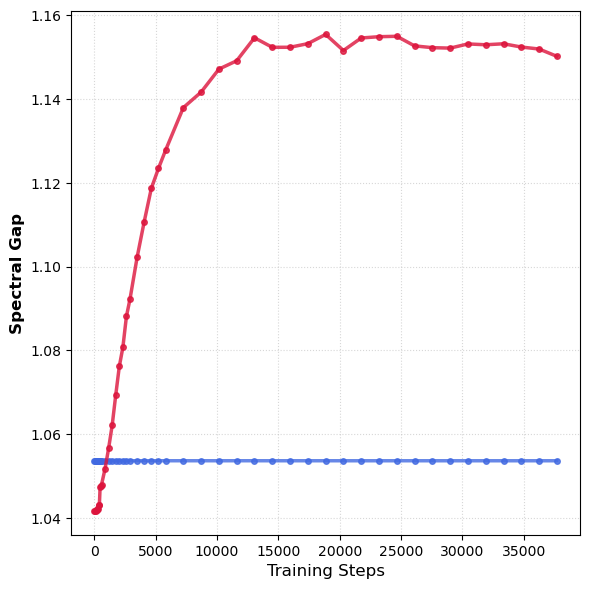

In [ ]:
STEPS_PER_EPOCH = 60000 // 1024  # Assuming batch size of 1024 for MNIST


def plot_single_run_structural_evolution(
    csv_path, a_target=1.2, s_target=0.25, metric="stable_rank"
):
    """
    Plots structural metrics (e.g., Stable Rank) for F0 and Classifier for one specific run.
    """
    df = pd.read_csv(csv_path)

    # 1. Filter for the Deep-Dive Run
    run_subset = df[(df["init_alpha"] == a_target) & (df["init_sigma"] == s_target)]

    if run_subset.empty:
        print(f"No data found for alpha={a_target}, sigma={s_target}")
        return

    # 2. Identify the Target Layers
    all_layers = run_subset["layer"].unique()
    f0_layer = [l for l in all_layers if "features.0" in l][0]
    cl_layer = [l for l in all_layers if "classifier" in l][0]

    # 3. Create Plot
    plt.figure(figsize=(6, 6))

    # Color logic to match your previous displacement plots
    colors = {f0_layer: "royalblue", cl_layer: "crimson"}
    labels = {f0_layer: "W0", cl_layer: "W10"}

    for layer in [f0_layer, cl_layer]:
        layer_data = run_subset[run_subset["layer"] == layer].sort_values("epoch")

        # Plot raw values
        plt.plot(
            layer_data["epoch"] * STEPS_PER_EPOCH,
            layer_data[metric],
            label=labels[layer],
            color=colors[layer],
            lw=2.5,
            marker="o",
            markersize=4,
            alpha=0.8,
        )

    # 4. Thesis-ready Aesthetics
    # plt.title(f"Structural Evolution: {metric.replace('_', ' ').title()}\n"
    #           f"Heavy-Tailed Regime: $\\alpha$={a_target}, $\\sigma$={s_target}",
    #           fontsize=16, fontweight='bold', pad=15)

    plt.xlabel("Training Steps", fontsize=12)
    plt.ylabel(f"{metric.replace('_', ' ').title()}", fontsize=12, fontweight="bold")

    plt.grid(True, linestyle=":", alpha=0.5)
    # plt.legend(frameon=True, shadow=True)

    # Add a note about the "Transition Point" if applicable
    # Based on the paper, weights often deviate from Gaussianity around Epoch 200
    # plt.axvline(x=200, color="gray", linestyle="--", alpha=0.4, label="Predicted Gaussian Deviation")

    plt.tight_layout()
    plt.savefig(f"{metric}_{a_target}_{s_target}.pdf", bbox_inches="tight")
    plt.show()


# Run for your specific case
plot_single_run_structural_evolution(
    "results/sweep_metrics.csv", a_target=1.2, s_target=0.25, metric="spectral_gap"
)

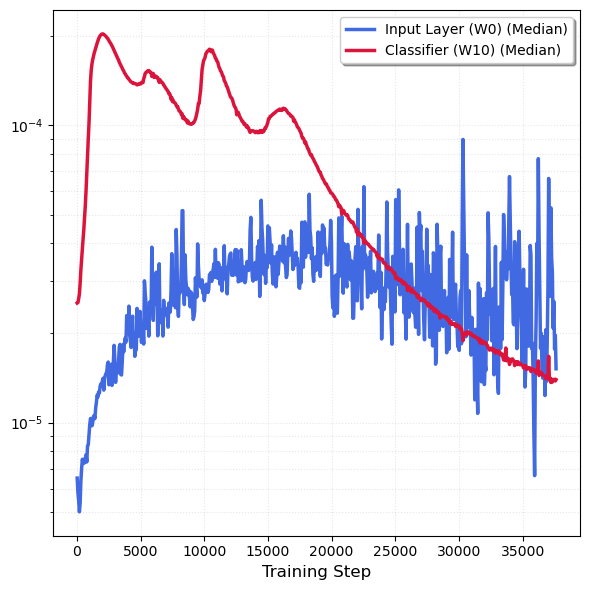

In [ ]:
# 1. Setup Parameters
ALPHA_VAL = 1.2
SIGMA_VAL = 0.25
LAYER_F0 = "features.0.weight"
LAYER_CL = "classifier.weight"
LAG = 58
WINDOW_SIZE = 1  # Recommended to smooth the 'stochastic jitter'

# Load DataFrame
msd_df = pd.read_parquet("displacement_database.parquet")


def get_rolling_stats(df, layer_name, window):
    subset = df.query(
        "alpha == @ALPHA_VAL and sigma == @SIGMA_VAL and layer == @layer_name and time_lag == @LAG"
    ).copy()
    subset = subset.sort_values("step")

    # Calculate Rolling Statistics
    subset["median"] = subset["l2_dist"].rolling(window=window, center=True).median()
    subset["q25"] = subset["l2_dist"].rolling(window=window, center=True).quantile(0.25)
    subset["q75"] = subset["l2_dist"].rolling(window=window, center=True).quantile(0.75)
    return subset


# Prepare both layers
df_f0 = get_rolling_stats(msd_df, LAYER_F0, WINDOW_SIZE)
df_cl = get_rolling_stats(msd_df, LAYER_CL, WINDOW_SIZE)

# 3. Create the Comparison Plot
fig, ax = plt.subplots(figsize=(6, 6))


# Helper to plot layer dynamics
def plot_layer(ax, df, color, label):
    # Shaded Noise Envelope
    # ax.fill_between(df["step"], df["q25"], df["q75"], color=color, alpha=0.2)
    # Median Trend Line
    ax.plot(df["step"], df["median"], color=color, lw=2.5, label=f"{label} (Median)")
    # Optional: Very light raw data
    ax.plot(df["step"], df["l2_dist"], color=color, alpha=0.2, lw=0.5)


# Plotting
plot_layer(ax, df_f0, color="royalblue", label="Input Layer (W0)")
plot_layer(ax, df_cl, color="crimson", label="Classifier (W10)")

# Formatting for Manuscript
ax.set_yscale("log")
ax.set_xlabel("Training Step", fontsize=12)
# ax.set_ylabel(f'L2 Displacement ($\\tau$={LAG})', fontsize=12, fontweight='bold')
# ax.set_title(f"Dynamical Decoupling: Initial vs. Final Layer\n$\\alpha$={ALPHA_VAL}, $\\sigma$={SIGMA_VAL} | Heavy-Tailed Regime",
#              fontsize=16, fontweight='bold', pad=20)

ax.grid(True, which="both", ls=":", alpha=0.3)
ax.legend(loc="upper right", frameon=True, shadow=True)

fig.tight_layout()
plt.savefig("layer_dynamics_slow.pdf", bbox_inches="tight")
plt.show()

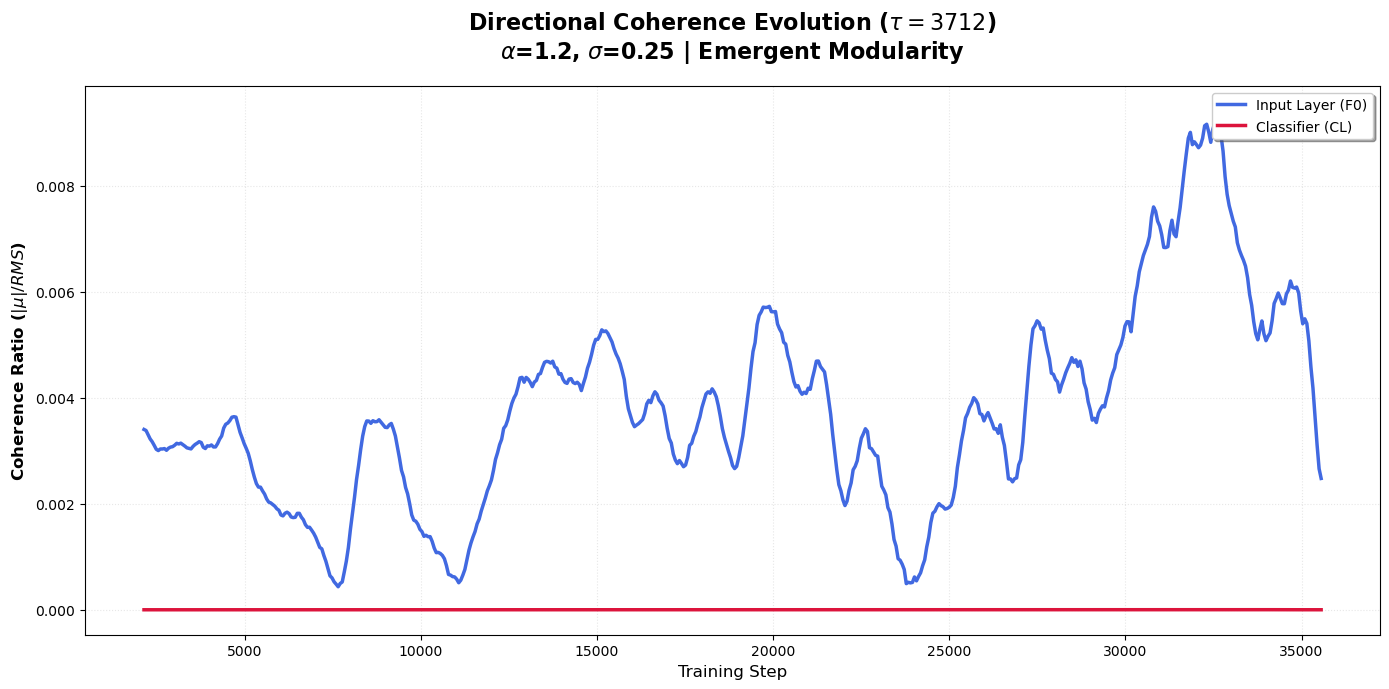

In [ ]:
# 1. Setup Parameters
ALPHA_VAL = 1.2
SIGMA_VAL = 0.25
STEPS_PER_EPOCH = 60000 // 1024
LAG_TO_PLOT = 58 * 64

# Explicitly defining the layers of interest for your "Two-Island" narrative
TARGET_LAYERS = ["features.0.weight", "classifier.weight"]
LAYER_LABELS = {
    "features.0.weight": "Input Layer (F0)",
    "classifier.weight": "Classifier (CL)",
}

# Load DataFrame
msd_df = pd.read_parquet("displacement_database.parquet")

# 2. Filter for the specific Alpha/Sigma run and selected layers
msd_filtered = msd_df.query(
    "alpha == @ALPHA_VAL and sigma == @SIGMA_VAL and time_lag == @LAG_TO_PLOT and layer in @TARGET_LAYERS"
)

# 3. Create the Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Define colors for the two distinct islands
colors = {"features.0.weight": "royalblue", "classifier.weight": "crimson"}

for layer in TARGET_LAYERS:
    layer_data = msd_filtered[msd_filtered["layer"] == layer].sort_values("step")

    # Calculate the Ratio: |Net Drift| / L2 Displacement
    # This measures 'Straightness' or 'Efficiency' of the weight movement
    coherence = layer_data["net_drift"].abs() / layer_data["l2_dist"]

    # Applying a rolling mean to highlight the 'Dynamical Horizon' shift
    # window=15 is a good balance for seeing the early search vs late stability
    coherence_smoothed = coherence.rolling(window=10, center=True).mean()

    ax1.plot(
        layer_data["step"],
        coherence_smoothed,
        label=f"{LAYER_LABELS[layer]}",
        color=colors[layer],
        lw=2.5,
    )

# Formatting for Manuscript
ax1.set_xlabel("Training Step", fontsize=12)
ax1.set_ylabel("Coherence Ratio ($|\\mu| / RMS$)", fontsize=12, fontweight="bold")
# ax1.set_ylim(0, 1.05)
ax1.tick_params(axis="y")

# Adding reference lines for physical interpretation
# ax1.axhline(0.5, ls='--', color='gray', alpha=0.5, label="High Coherence Threshold")

# Final Polish
plt.title(
    f"Directional Coherence Evolution ($\\tau={LAG_TO_PLOT}$)\n$\\alpha$={ALPHA_VAL}, $\\sigma$={SIGMA_VAL} | Emergent Modularity",
    fontsize=16,
    fontweight="bold",
    pad=20,
)

ax1.grid(True, which="both", ls=":", alpha=0.3)
ax1.legend(loc="upper right", frameon=True, shadow=True)
fig.tight_layout()

# plt.savefig("directional_coherence_comparison.pdf", bbox_inches="tight")
plt.show()

Layer W0: Gamma = 0.721 ± 0.047 (R²=0.987)
Layer W10: Gamma = 1.136 ± 0.133 (R²=0.959)


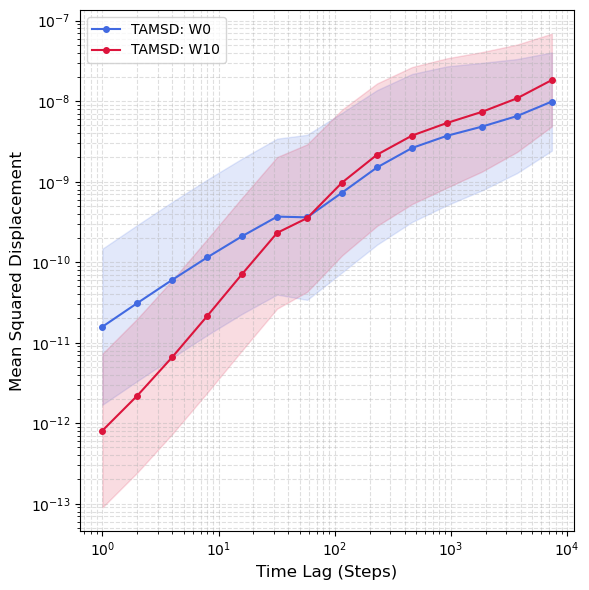

In [64]:
def calculate_tamsd(df, layer_name, alpha_val=1.2, sigma_val=0.25):
    subset = df.query(
        "alpha == @alpha_val and sigma == @sigma_val and layer == @layer_name"
    )

    def get_stats(x):
        squared_x = np.square(x)
        # Avoid log(0) issues
        log_squared_x = np.log(squared_x[squared_x > 0])
        return pd.Series(
            {
                "msd": np.mean(squared_x),
                "log_std": np.std(log_squared_x) if len(log_squared_x) > 0 else 0,
                "count": len(x),
            }
        )

    stats = (
        subset.groupby("time_lag")["l2_dist"].apply(get_stats).unstack().reset_index()
    )
    stats.columns = ["lag", "msd", "log_std", "count"]
    return stats


def plot_tamsd_comparison(parquet_path, alpha_val, sigma_val, layers_to_compare):
    df = pd.read_parquet(parquet_path)
    plt.figure(figsize=(6, 6))

    for layer in layers_to_compare:
        res = calculate_tamsd(df, layer, alpha_val=alpha_val, sigma_val=sigma_val)

        # Determine color/label
        is_w0 = layer == "features.0.weight"
        color = "royalblue" if is_w0 else "crimson"
        label_base = "W0" if is_w0 else "W10"

        # Geometric Bounds: Multiply/Divide by the exponent of log_std
        # This creates a "multiplicative" ribbon that looks clean on log scales
        lower_bound = res["msd"] / np.exp(res["log_std"])
        upper_bound = res["msd"] * np.exp(res["log_std"])

        plt.fill_between(res["lag"], lower_bound, upper_bound, color=color, alpha=0.15)

        # 2. Plot the Mean TAMSD line
        plt.loglog(
            res["lag"],
            res["msd"],
            marker="o",
            markersize=4,
            color=color,
            label=f"TAMSD: {label_base}",
        )

        # 3. STATISTICAL RIGOR: Linear Regression on Log-Log
        # We only fit the first 20% of the lags to avoid the noisy tail/bend artifacts
        # or fit the whole thing to see the "average" gamma.
        log_lag = np.log(res["lag"].values)
        log_msd = np.log(res["msd"].values)

        # linregress returns slope, intercept, r_value, p_value, and stderr
        slope, intercept, r_val, p_val, stderr = stats.linregress(log_lag, log_msd)

        # Calculate 95% CI for the slope (gamma)
        # t_crit is approx 1.96 for large N
        ci_gamma = 1.96 * stderr

        print(
            f"Layer {label_base}: Gamma = {slope:.3f} ± {ci_gamma:.3f} (R²={r_val**2:.3f})"
        )

    # Formatting
    plt.xlabel("Time Lag (Steps)", fontsize=12)
    plt.ylabel("Mean Squared Displacement", fontsize=12)
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.savefig("tamsd_comparison.pdf")
    plt.show()


# Example usage:
plot_tamsd_comparison(
    "displacement_database.parquet", 2.0, 3.0, ["features.0.weight", "classifier.weight"]
)

Steps 0-5000: Gamma = 1.197 ± 0.127 (R²=0.966)
Steps 15000-20000: Gamma = 0.942 ± 0.081 (R²=0.977)
Steps 33000-38000: Gamma = 0.838 ± 0.037 (R²=0.994)


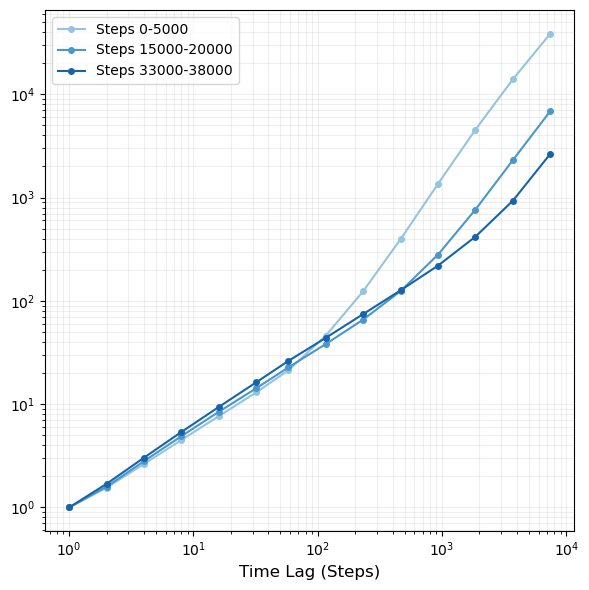

In [ ]:
def calculate_tamsd_windowed(
    df, layer_name, window_range, alpha_val=1.2, sigma_val=0.25
):
    """
    Calculates TAMSD for a specific layer within a specific training window.
    window_range: tuple (start_step, end_step)
    """
    subset = df.query(
        "alpha == @alpha_val and sigma == @sigma_val and layer == @layer_name and step >= @window_range[0] and step < @window_range[1]"
    )

    def get_stats(x):
        squared_x = np.square(x)
        # Avoid log(0) issues
        log_squared_x = np.log(squared_x[squared_x > 0])
        return pd.Series(
            {
                "msd": np.mean(squared_x),
                "log_std": np.std(log_squared_x) if len(log_squared_x) > 0 else 0,
                "count": len(x),
            }
        )

    stats = (
        subset.groupby("time_lag")["l2_dist"].apply(get_stats).unstack().reset_index()
    )
    stats.columns = ["lag", "msd", "log_std", "count"]
    return stats


def plot_layer_evolution_tamsd(parquet_path, layer_name, windows):
    """
    Plots the TAMSD curves for a single layer across different training stages.
    windows: list of tuples [(start, end), ...]
    """
    df = pd.read_parquet(parquet_path)
    plt.figure(figsize=(6, 6))

    # Use a colormap to show progression (e.g., from light to dark)
    colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(windows)))

    for i, window in enumerate(windows):
        res = calculate_tamsd_windowed(df, layer_name, window)

        if res is not None:
            label = f"Steps {window[0]}-{window[1]}"
            # Geometric Bounds: Multiply/Divide by the exponent of log_std
            # This creates a "multiplicative" ribbon that looks clean on log scales
            # 1. Get the normalization constant (MSD at the first lag)
            # Assuming your 'res' dataframe is sorted by lag
            msd_tau_1 = res["msd"].iloc[0]

            # Create normalized versions for plotting
            norm_msd = res["msd"] / msd_tau_1

            # 3. Plot the Normalized Mean TAMSD line
            # Now every line will strictly start at (1, 1) on the log-log plot
            plt.loglog(
                res["lag"],
                norm_msd,
                marker="o",
                markersize=4,
                color=colors[i],
                label=label,
            )

            # 4. STATISTICAL RIGOR (on normalized log values)
            log_lag = np.log(res["lag"].values)
            log_norm_msd = np.log(norm_msd.values)

            slope, intercept, r_val, p_val, stderr = stats.linregress(
                log_lag, log_norm_msd
            )

            # The slope (gamma) will be IDENTICAL to the non-normalized version,
            # but the intercept will now be 0 (since log(1) = 0).
            ci_gamma = 1.96 * stderr
            print(f"{label}: Gamma = {slope:.3f} ± {ci_gamma:.3f} (R²={r_val**2:.3f})")

    # plt.title(f"Evolution of Diffusion Horizon: {layer_name}", fontsize=15, fontweight='bold')
    plt.xlabel("Time Lag (Steps)", fontsize=12)
    # plt.ylabel("Mean Squared Displacement (TAMSD)", fontsize=12)
    plt.legend()
    plt.grid(True, which="both", alpha=0.2)
    plt.tight_layout()
    plt.savefig(f"tamsd_evolution_{layer_name}.pdf")
    plt.show()


# Example usage for your Honours Analysis:
# Define windows that represent early, middle, and late training
training_windows = [
    (0, 5000),  # Early exploration
    (15000, 20000),  # Mid-training
    (33000, 38000),  # Late convergence
]

plot_layer_evolution_tamsd(
    "displacement_database.parquet", "features.0.weight", training_windows
)

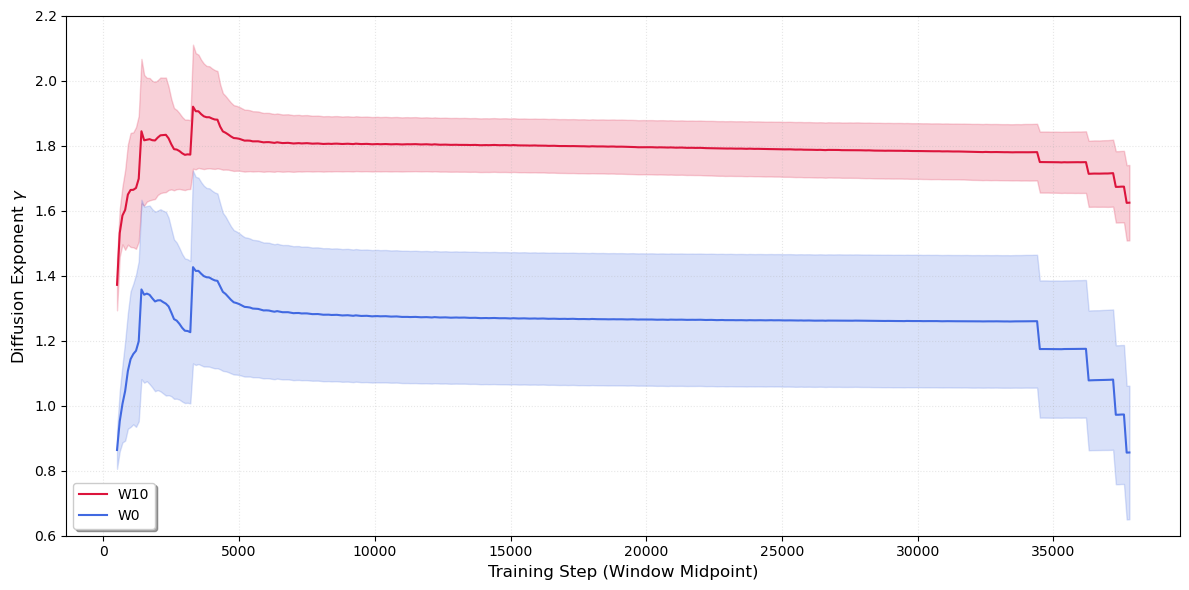

In [63]:
def calculate_rolling_tamsd(
    msd_df, layer_name, alpha=1.2, sigma=0.25, window_size=2000, stride=200
):
    """
    Calculates the evolution of the diffusion exponent gamma over training time.
    """
    subset = msd_df[
        (msd_df["layer"] == layer_name)
        & (msd_df["alpha"] == alpha)
        & (np.isclose(msd_df["sigma"], sigma))
    ].copy()

    subset = subset.sort_values(["step", "time_lag"])
    all_steps = sorted(subset["step"].unique())
    n_steps = len(all_steps)
    results = []

    for start_idx in range(0, n_steps - window_size, stride):
        end_idx = start_idx + window_size
        window_steps = all_steps[start_idx:end_idx]
        window_data = subset[subset["step"].isin(window_steps)]

        # Calculate MSD: Mean of squared L2 displacements
        tamsd_data = (
            window_data.groupby("time_lag")["l2_dist"]
            .apply(lambda x: np.mean(x**2))
            .reset_index()
        )
        tamsd_data = tamsd_data[tamsd_data["l2_dist"] > 0]

        if len(tamsd_data) > 3:
            log_tau = np.log10(tamsd_data["time_lag"])
            log_msd = np.log10(tamsd_data["l2_dist"])

            # Use linregress to get stderr and r_value
            slope, intercept, r_val, p_val, stderr = linregress(log_tau, log_msd)

            midpoint_step = (window_steps[0] + window_steps[-1]) / 2

            results.append(
                {
                    "step": midpoint_step,
                    "gamma": slope,
                    "r2": r_val**2,
                    "stderr": stderr,  # This is the "Honesty Metric"
                }
            )

    return pd.DataFrame(results)


# 1. Setup and Data Loading
msd_df = pd.read_parquet("displacement_database.parquet")
ALPHA_VAL = 2.0
SIGMA_VAL = 3.0
layer_engine = "classifier.weight"  # The Terminal Layer
layer_reservoir = "features.0.weight"  # The Initial Layer

# 2. Compute Dynamics for both
rolling_engine = calculate_rolling_tamsd(
    msd_df, layer_engine, alpha=ALPHA_VAL, sigma=SIGMA_VAL
)
rolling_reservoir = calculate_rolling_tamsd(
    msd_df, layer_reservoir, alpha=ALPHA_VAL, sigma=SIGMA_VAL
)

# 3. Plotting
plt.figure(figsize=(12, 6))

# The Terminal Layer (Blue) + Confidence Ribbon
plt.fill_between(
    rolling_engine["step"],
    rolling_engine["gamma"] - 1.96 * rolling_engine["stderr"],
    rolling_engine["gamma"] + 1.96 * rolling_engine["stderr"],
    color="crimson",
    alpha=0.2,
)
plt.plot(rolling_engine["step"], rolling_engine["gamma"], color="crimson", label="W10")

# The Initial Layer (Orange) + Confidence Ribbon
# NOTE: This ribbon will be MUCH wider where the "bend" is severe
plt.fill_between(
    rolling_reservoir["step"],
    rolling_reservoir["gamma"] - 1.96 * rolling_reservoir["stderr"],
    rolling_reservoir["gamma"] + 1.96 * rolling_reservoir["stderr"],
    color="royalblue",
    alpha=0.2,
)
plt.plot(
    rolling_reservoir["step"], rolling_reservoir["gamma"], color="royalblue", label="W0"
)

# Physics Reference Lines
# plt.axhline(y=1.0, color='firebrick', linestyle='--', alpha=0.5, label='Brownian Limit ($\gamma=1$)')
# plt.axhline(y=2.0, color='forestgreen', linestyle='--', alpha=0.5, label='Ballistic Limit ($\gamma=2$)')

# Final Polish
# plt.title(f"Visualizing Spatial Decoupling\n($\\alpha$={ALPHA_VAL}, $\\sigma$={SIGMA_VAL})",
#           fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Training Step (Window Midpoint)", fontsize=12)
plt.ylabel(r"Diffusion Exponent $\gamma$", fontsize=12)
plt.ylim(0.6, 2.2)
plt.grid(True, which="both", ls=":", alpha=0.3)
plt.legend(loc="lower left", frameon=True, shadow=True)

plt.tight_layout()
plt.savefig("diffusion_curve.pdf", bbox_inches="tight")  # Save as PDF for high quality
plt.show()

Applying RMT Denoising (Q=3834.90)...


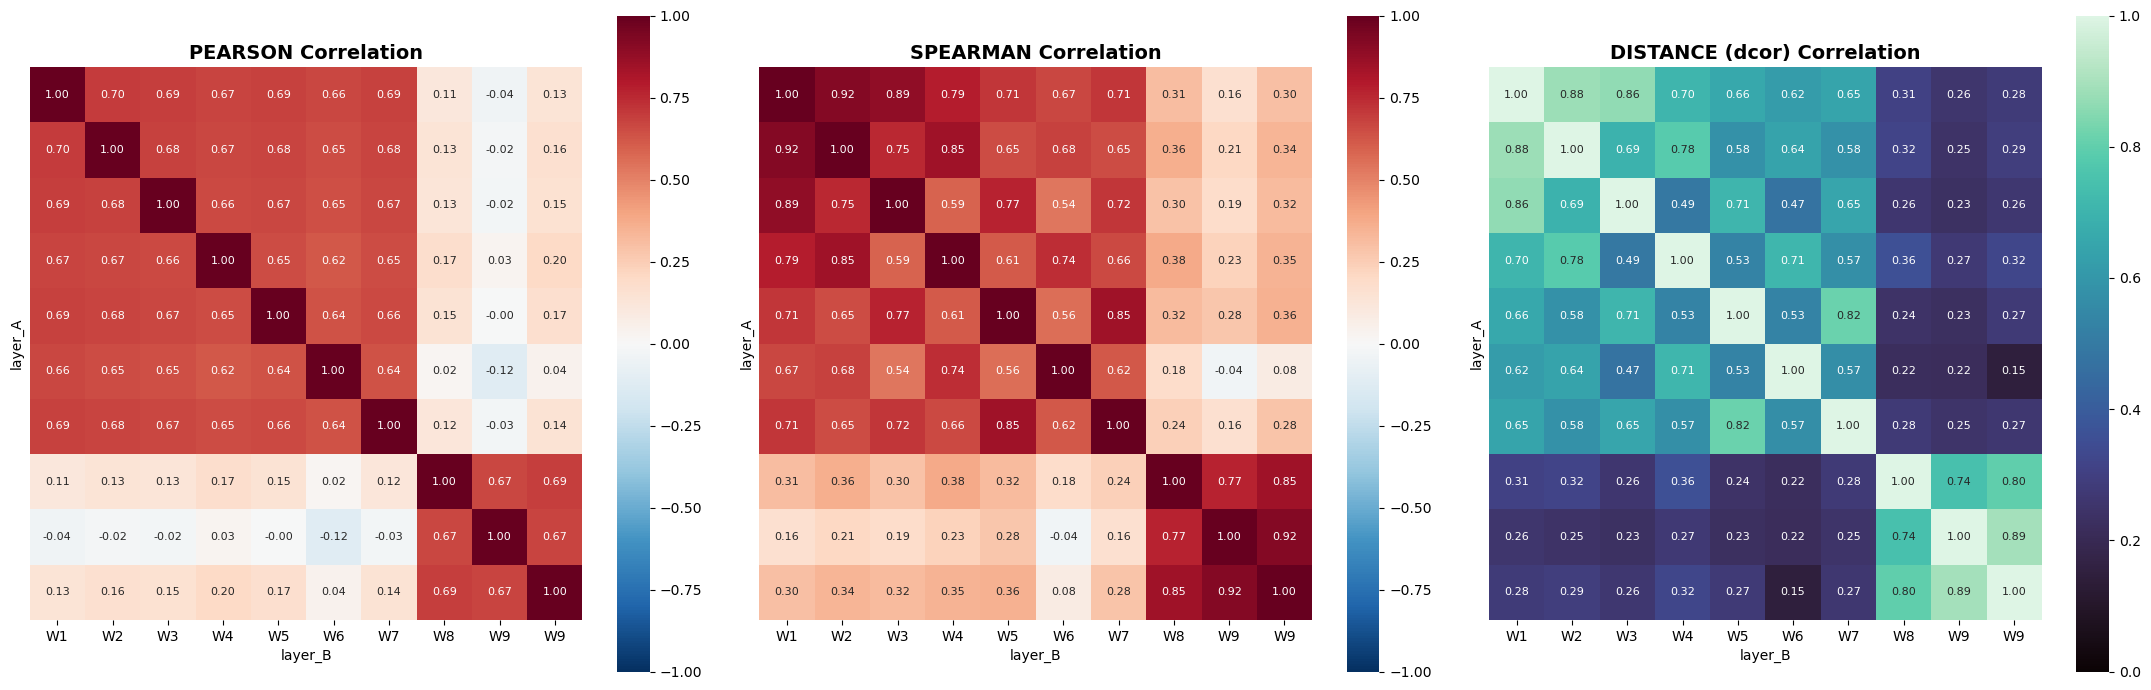

In [ ]:
def denoise_matrix(df_matrix, Q):
    """
    Applies Marchenko-Pastur Eigenvalue Clipping to a correlation matrix.
    Q = T / N (Number of observations / Number of variables)
    """
    # 1. Eigen-decomposition
    vals, vecs = np.linalg.eigh(df_matrix)

    # 2. Determine Marchenko-Pastur Upper Bound (lambda_plus)
    # sigma^2 is assumed to be 1 for a correlation matrix
    lambda_plus = (1 + np.sqrt(1 / Q)) ** 2

    # 3. Identify the "Bulk" (noise) vs "Signal"
    indices_bulk = vals <= lambda_plus
    indices_signal = vals > lambda_plus

    if not np.any(indices_bulk):
        return df_matrix  # No noise found to clip

    # 4. Clipping: Replace bulk eigenvalues with their average
    # This preserves the Trace (sum of eigenvalues = N)
    avg_bulk = np.mean(vals[indices_bulk])
    vals_denoised = np.copy(vals)
    vals_denoised[indices_bulk] = avg_bulk

    # 5. Reconstruct the cleaned matrix
    cleaned_mat = vecs @ np.diag(vals_denoised) @ vecs.T

    # 6. Re-normalize to ensure diagonals are exactly 1 (it's a correlation matrix)
    d = np.diag(cleaned_mat)
    cleaned_mat = cleaned_mat / np.sqrt(np.outer(d, d))

    return pd.DataFrame(cleaned_mat, index=df_matrix.index, columns=df_matrix.columns)


def compute_and_plot_trinity(
    parquet_path, alpha_val, sigma_val, time_lag=1, metric_col="l2_dist", denoise=False
):
    """
    Computes Pearson, Spearman, and Distance Correlation.
    If denoise=True, applies RMT cleaning to the Pearson matrix.
    """
    df_full = pd.read_parquet(parquet_path)

    subset = df_full[
        (df_full["alpha"] == alpha_val)
        & (np.isclose(df_full["sigma"], sigma_val))
        & (df_full["time_lag"] == time_lag)
    ].copy()

    if subset.empty:
        return

    ts_matrix = subset.pivot(index="step", columns="layer", values=metric_col).dropna()
    layers = ts_matrix.columns.tolist()

    # Calculate Raw Matrices
    pearson_mat = ts_matrix.corr(method="pearson")
    spearman_mat = ts_matrix.corr(method="spearman")

    # Apply RMT Denoising if toggled
    if denoise:
        # Q = Number of steps / Number of layers
        Q_ratio = ts_matrix.shape[0] / ts_matrix.shape[1]
        print(f"Applying RMT Denoising (Q={Q_ratio:.2f})...")
        pearson_mat = denoise_matrix(pearson_mat, Q_ratio)
        # Note: We usually keep Spearman raw or apply similar logic,
        # but for Honours, denoising the primary Linear metric (Pearson) is the standard move.

    # Distance Correlation
    n_layers = len(layers)
    dcor_mat = pd.DataFrame(np.ones((n_layers, n_layers)), index=layers, columns=layers)
    for i in range(n_layers):
        for j in range(i + 1, n_layers):
            val = dcor.distance_correlation(ts_matrix.iloc[:, i], ts_matrix.iloc[:, j])
            dcor_mat.iloc[i, j] = dcor_mat.iloc[j, i] = val

    # Melt and Plot
    def melt_matrix(mat):
        mat.index.name = "layer_A"
        return mat.reset_index().melt(
            id_vars="layer_A", var_name="layer_B", value_name="correlation"
        )

    df_p = melt_matrix(pearson_mat)
    df_s = melt_matrix(spearman_mat)
    df_d = melt_matrix(dcor_mat)

    plot_correlation_trinity(df_p, df_s, df_d, alpha_val, sigma_val, delta_t=time_lag)


def plot_correlation_trinity(
    pearson_df, spearman_df, dcor_df, alpha_val, sigma_val, delta_t=1
):
    """
    Your original plotting function with minor tweaks to handle the DataFrame format.
    """
    fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

    methods = [
        ("PEARSON", pearson_df, "RdBu_r", (-1, 1)),
        ("SPEARMAN", spearman_df, "RdBu_r", (-1, 1)),
        ("DISTANCE (dcor)", dcor_df, "mako", (0, 1)),
    ]

    def sort_key(name):
        # Sorts features.0, features.16, classifier...
        nums = re.findall(r"\d+", name)
        if "classifier" in name.lower():
            return 999
        return int(nums[0]) if nums else 0

    for i, (name, df, cmap, (vmin, vmax)) in enumerate(methods):
        ax = axes[i]

        # Standardize matrix for heatmap
        matrix = df.pivot(index="layer_A", columns="layer_B", values="correlation")
        ordered = sorted(matrix.index.tolist(), key=sort_key)
        matrix = matrix.reindex(index=ordered, columns=ordered)

        short_labels = [
            f"W{(int(re.findall(r'\d+', l)[0]) // 2) + 1}"
            if "features" in l
            else f"W{len(ordered) - 1}"
            for l in ordered
        ]

        sns.heatmap(
            matrix,
            ax=ax,
            annot=True,
            fmt=".2f",
            annot_kws={"size": 8},
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            square=True,
            cbar=True,
            xticklabels=short_labels,
            yticklabels=short_labels if i == 0 else False,
        )

        ax.set_title(f"{name} Correlation", fontsize=14, fontweight="bold")

    # plt.suptitle(f"Metric Comparison | $\\alpha$={alpha_val}, $\\sigma$={sigma_val} | Lag={delta_t}",
    #              fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig("correlations.pdf", bbox_inches="tight")  # Save as PDF for high quality
    plt.show()


# EXECUTION:
compute_and_plot_trinity(
    "displacement_database.parquet",
    alpha_val=1.2,
    sigma_val=0.25,
    time_lag=1,
    denoise=True,
)

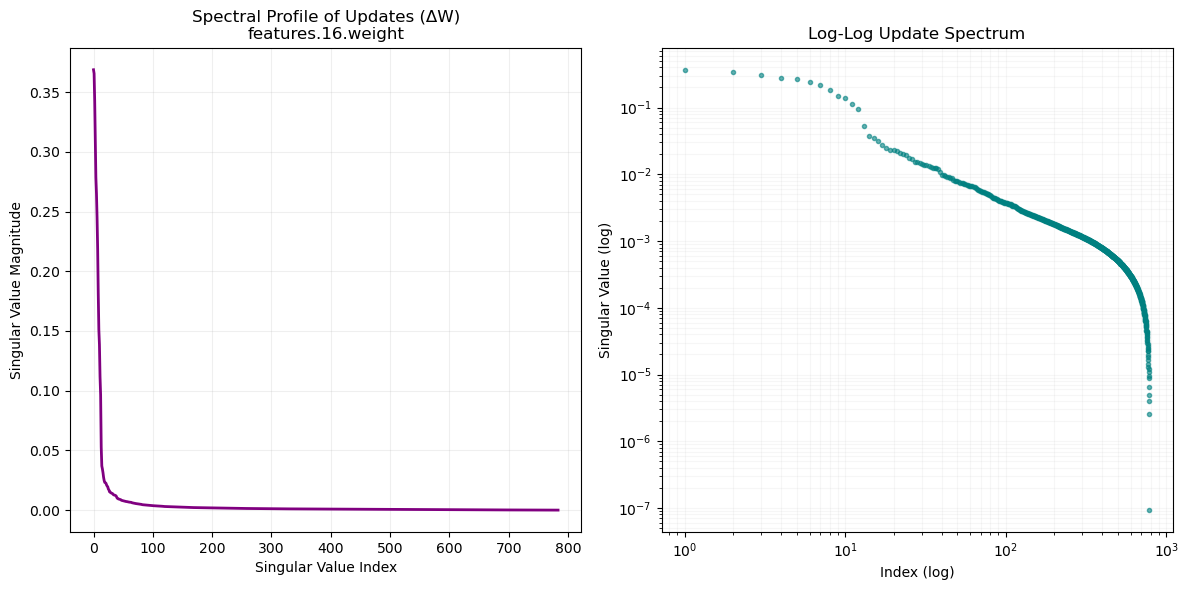

--- Kinetic Spectral Analysis ---
Stable Rank of ΔW: 6.269
Spectral Gap of ΔW: 1.009


In [73]:
RUN_PATH = Path("training_runs/mnist_mlp_sweep/alpha_1.2_g_1.0/GeneralMLP_LR0.001_BS1024_20260318_122537_s0")
run_df = collect_run_snapshots(RUN_PATH)

# 1. Configuration: Define the window for kinetic analysis
TARGET_LAYER = "features.16.weight"  # Referred to as W10 in your manuscript [cite: 169]
EPOCH_START = 0                    # Initial state (t-tau)
EPOCH_END = 650                    # Final state (t)
TARGET_SHAPE = (784, 784)           # 10 classes, 784 features [cite: 98, 102]

# 2. Filtering and Extraction for both snapshots
df_start = run_df[(run_df['layer'] == TARGET_LAYER) & (run_df['epoch'] == EPOCH_START)]
df_end = run_df[(run_df['layer'] == TARGET_LAYER) & (run_df['epoch'] == EPOCH_END)]

if not df_start.empty and not df_end.empty:
    # Calculate ΔW (The displacement matrix) [cite: 43]
    w_start = df_start['weights'].iloc[0].reshape(TARGET_SHAPE)
    w_end = df_end['weights'].iloc[0].reshape(TARGET_SHAPE)
    delta_w = w_end - w_start

    # 1. Perform Singular Value Decomposition (SVD) on the displacement matrix [cite: 74]
    # We use torch for speed on the 784x784 matrix
    delta_w_tensor = torch.from_numpy(delta_w).float()
    _, S_delta, _ = torch.linalg.svd(delta_w_tensor, full_matrices=False)
    s_delta_np = S_delta.numpy()

    # 2. Visualization: Spectral Density of Updates
    plt.figure(figsize=(12, 6))

    # Plot 1: The Scree Plot (Linear scale to see dominant experts) [cite: 75]
    plt.subplot(1, 2, 1)
    plt.plot(s_delta_np, color='purple', lw=2)
    plt.title(f"Spectral Profile of Updates (ΔW)\n{TARGET_LAYER}")
    plt.xlabel("Singular Value Index")
    plt.ylabel("Singular Value Magnitude")
    plt.grid(alpha=0.2)

    # Plot 2: Log-Log Spectrum (To identify power-law learning kinetics) [cite: 213]
    plt.subplot(1, 2, 2)
    plt.loglog(s_delta_np, marker='.', linestyle='none', color='teal', alpha=0.6)
    plt.title("Log-Log Update Spectrum")
    plt.xlabel("Index (log)")
    plt.ylabel("Singular Value (log)")
    plt.grid(True, which="both", ls="-", alpha=0.1)

    plt.tight_layout()
    plt.show()

    # 3. Physics Observables: Spectral Denoising
    # Calculate the Stable Rank of the UPDATES to see effective dimensionality
    stable_rank_delta = (np.sum(s_delta_np**2)) / (s_delta_np[0]**2)

    # Calculate Spectral Gap of updates
    spectral_gap_delta = s_delta_np[0] / s_delta_np[1] if len(s_delta_np) > 1 else 0

    print(f"--- Kinetic Spectral Analysis ---")
    print(f"Stable Rank of ΔW: {stable_rank_delta:.3f}")
    print(f"Spectral Gap of ΔW: {spectral_gap_delta:.3f}")